# Heterogeneous sensors and physical calibration

Combine different supports without pretending they are identical points. Noise controls their relative influence. CML attenuation involves the path integral of a power law aRᵇ; averaging rain then applying the power law can be biased.

**Objective:** reconstruct with heterogeneous noise and expose nonlinear averaging.

In [1]:
from pathlib import Path
import os
if Path.cwd().name == 'tutorials': os.chdir('..')
import numpy as np
import matplotlib.pyplot as plt
from fieldlab import Grid, points, lines, footprints, projections, combine
from fieldlab.fields import simulate, sensor_layout
from fieldlab.operators import observe
from fieldlab.models import idw, tikhonov, gaussian_process, total_variation, heat_reconstruction


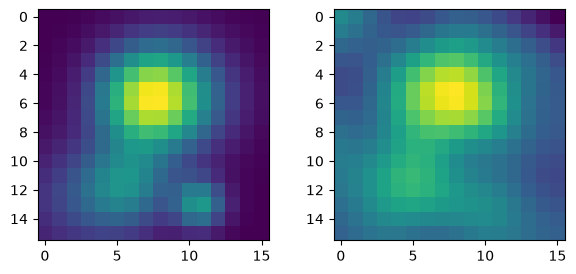

Mean rain power: 13.132639022018838 Mean attenuation factor: 17.317367684809486


In [2]:
grid=Grid((16,16)); truth=simulate(grid,41)
A,layout=sensor_layout(grid,20,15,8,seed=10)
noise=np.r_[np.full(20,.02),np.full(15,.05),np.full(8,.10)]
y=observe(A,truth,noise,seed=11); r=gaussian_process(grid,A,y,noise=noise)
fig,axes=plt.subplots(1,2,figsize=(7,3)); axes[0].imshow(truth); axes[1].imshow(r.mean); plt.show()
rain=np.array([1.,9.]); exponent=1.6
print('Mean rain power:',rain.mean()**exponent,'Mean attenuation factor:',np.mean(rain**exponent))
assert not np.isclose(rain.mean()**exponent,np.mean(rain**exponent))


**Exercise:** corrupt one sensor family with bias; explain why larger independent noise does not fix systematic bias. Add a calibration parameter or quality-control step. Load your own CSV using the documented schema, retaining units and source metadata.

See [theory notes](../docs/theory.md) for assumptions and equations.